<a href="https://colab.research.google.com/github/Mickey5480/Data110-Fall2025/blob/main/Final_Project_Street_Lights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip -q install leafmap maplibre pandas pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 632.9/632.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.2/208.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.2 MB/s eta 0:00:00


In [10]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving Street_Lights_(excludes_PEPCO%2C_developer).csv to Street_Lights_(excludes_PEPCO%2C_developer) (1).csv


In [16]:
import pandas as pd

df = pd.read_csv("Street_Lights_(excludes_PEPCO%2C_developer).csv")
df.head()

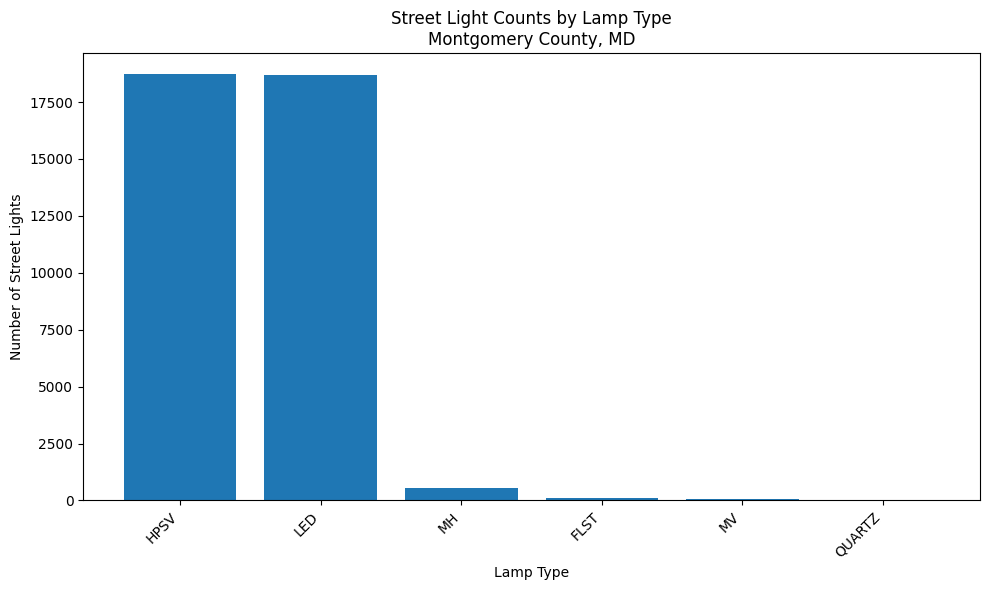

In [18]:
lamp_counts = df['LAMP_TYPE'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(lamp_counts.index, lamp_counts.values)
plt.xlabel("Lamp Type")
plt.ylabel("Number of Street Lights")
plt.title("Street Light Counts by Lamp Type\nMontgomery County, MD")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

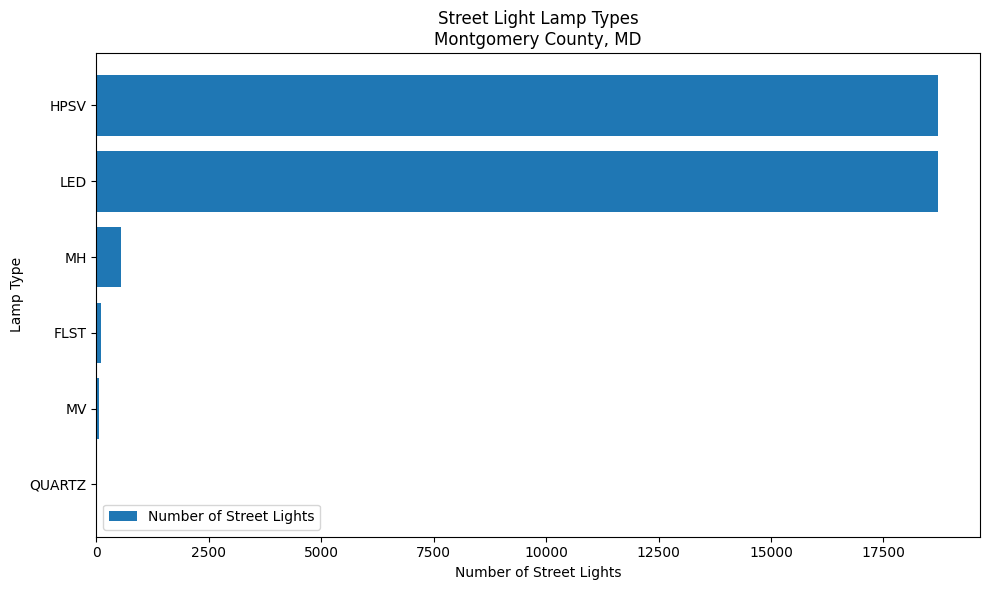

In [21]:
lamp_counts = df['LAMP_TYPE'].value_counts().sort_values()

plt.figure(figsize=(10, 6))
plt.barh(
    lamp_counts.index,
    lamp_counts.values,
    label="Number of Street Lights"
)
plt.xlabel("Number of Street Lights")
plt.ylabel("Lamp Type")
plt.title(
    "Street Light Lamp Types\nMontgomery County, MD"
)

plt.legend()
plt.tight_layout()
plt.show()

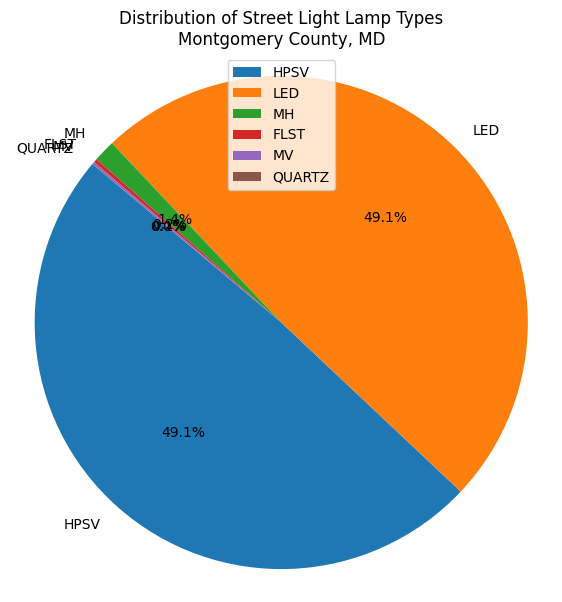

In [17]:
import matplotlib.pyplot as plt
lamp_counts = df['LAMP_TYPE'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    lamp_counts,
    labels=lamp_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Distribution of Street Light Lamp Types\nMontgomery County, MD")
plt.axis('equal')  # makes pie a circle
plt.legend()
plt.show()


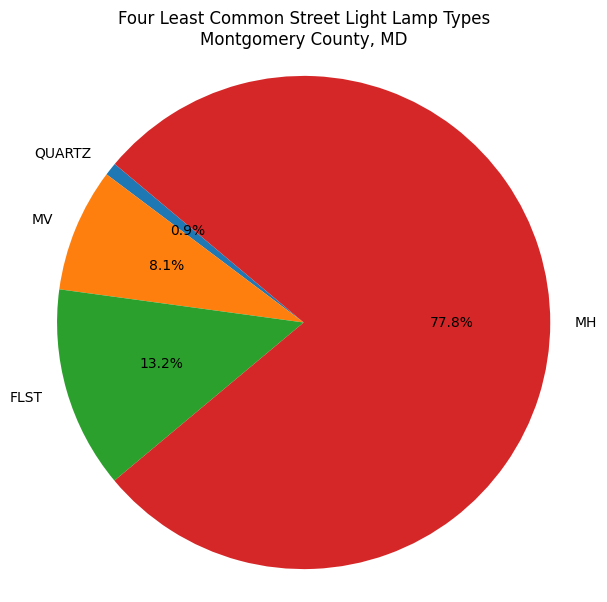

In [22]:
lamp_counts = df['LAMP_TYPE'].value_counts()
smallest_4 = lamp_counts.sort_values().head(4)

plt.figure(figsize=(7, 7))
plt.pie(
    smallest_4.values,
    labels=smallest_4.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title(
    "Four Least Common Street Light Lamp Types\nMontgomery County, MD")

plt.axis('equal')
plt.show()

<Figure size 1200x600 with 0 Axes>

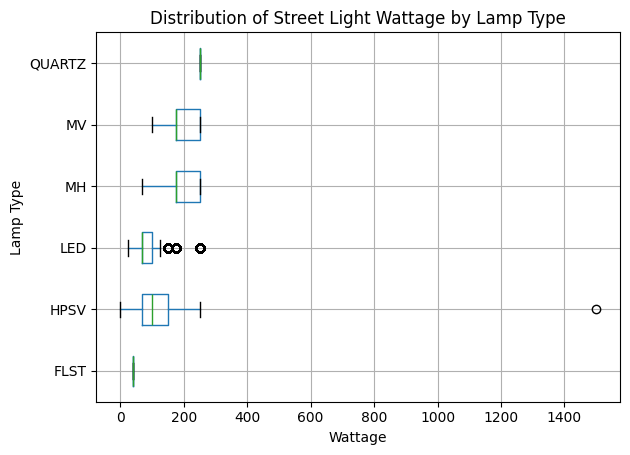

In [23]:
import matplotlib.pyplot as plt
box_data = df[['LAMP_TYPE', 'WATTAGE']].dropna()

plt.figure(figsize=(12, 6))
box_data.boxplot(
    column='WATTAGE',
    by='LAMP_TYPE',
    vert=False
)
plt.title("Distribution of Street Light Wattage by Lamp Type")
plt.suptitle("")
plt.xlabel("Wattage")
plt.ylabel("Lamp Type")

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

# Build figure data structure
lamp_figure_df = (
    df['LAMP_TYPE']
    .value_counts()
    .rename_axis('Lamp_Type')
    .reset_index(name='Count')
)

# Add percentage column
lamp_figure_df['Percentage'] = (
    lamp_figure_df['Count'] / lamp_figure_df['Count'].sum() * 100
).round(2)

lamp_figure_df

,Lamp_Type,Count,Percentage
0,HPSV,18711,49.09
1,LED,18704,49.07
2,MH,547,1.44
3,FLST,93,0.24
4,MV,57,0.15
5,QUARTZ,6,0.02


from matplotlib import pyplot as plt
lamp_figure_df['Count'].plot(kind='hist', bins=20, title='Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
lamp_figure_df['Percentage'].plot(kind='hist', bins=20, title='Percentage')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
lamp_figure_df.groupby('Lamp_Type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
lamp_figure_df.plot(kind='scatter', x='Count', y='Percentage', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
lamp_figure_df['Count'].plot(kind='line', figsize=(8, 4), title='Count')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
lamp_figure_df['Percentage'].plot(kind='line', figsize=(8, 4), title='Percentage')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(lamp_figure_df['Lamp_Type'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(lamp_figure_df, x='Count', y='Lamp_Type', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(lamp_figure_df['Lamp_Type'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(lamp_figure_df, x='Percentage', y='Lamp_Type', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

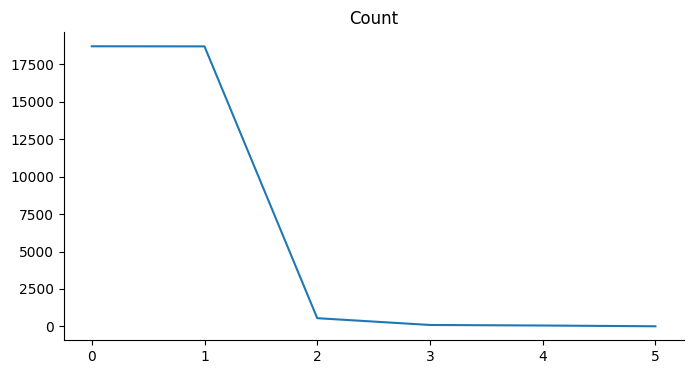

In [29]:
from matplotlib import pyplot as plt
lamp_figure_df['Count'].plot(kind='line', figsize=(8, 4), title='Count')
plt.gca().spines[['top', 'right']].set_visible(False)

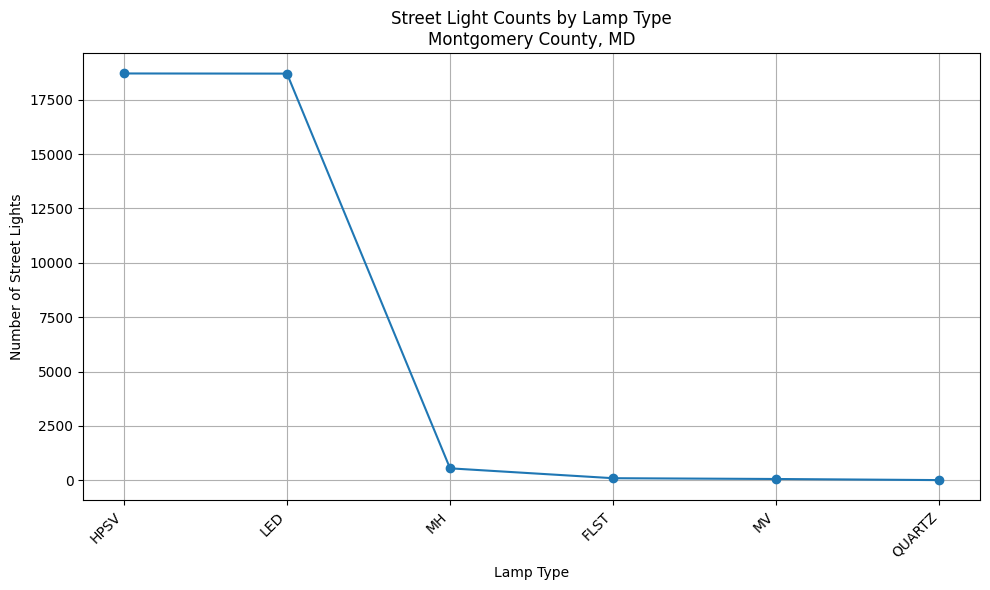

In [33]:
import matplotlib.pyplot as plt

# Ensure data is sorted (largest to smallest for clarity)
lamp_line_df = lamp_figure_df.sort_values('Count', ascending=False)

plt.figure(figsize=(10, 6))

plt.plot(
    lamp_line_df['Lamp_Type'],
    lamp_line_df['Count'],
    marker='o'
)

plt.xlabel("Lamp Type")
plt.ylabel("Number of Street Lights")
plt.title("Street Light Counts by Lamp Type\nMontgomery County, MD")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.show()

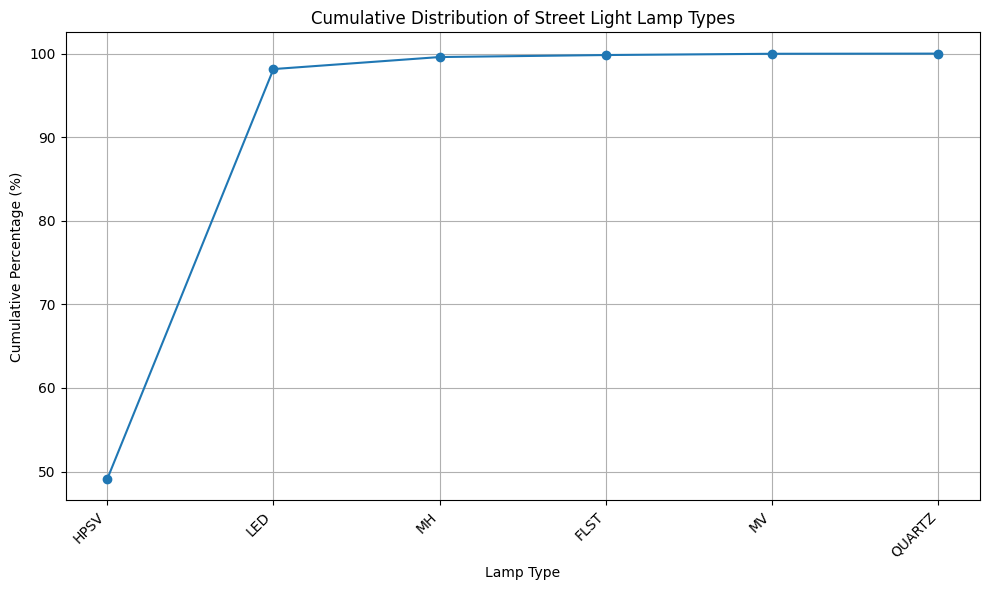

In [31]:
lamp_line_df['Cumulative_Percentage'] = lamp_line_df['Percentage'].cumsum()

plt.figure(figsize=(10,6))
plt.plot(
    lamp_line_df['Lamp_Type'],
    lamp_line_df['Cumulative_Percentage'],
    marker='o'
)

plt.xlabel("Lamp Type")
plt.ylabel("Cumulative Percentage (%)")
plt.title("Cumulative Distribution of Street Light Lamp Types")

plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

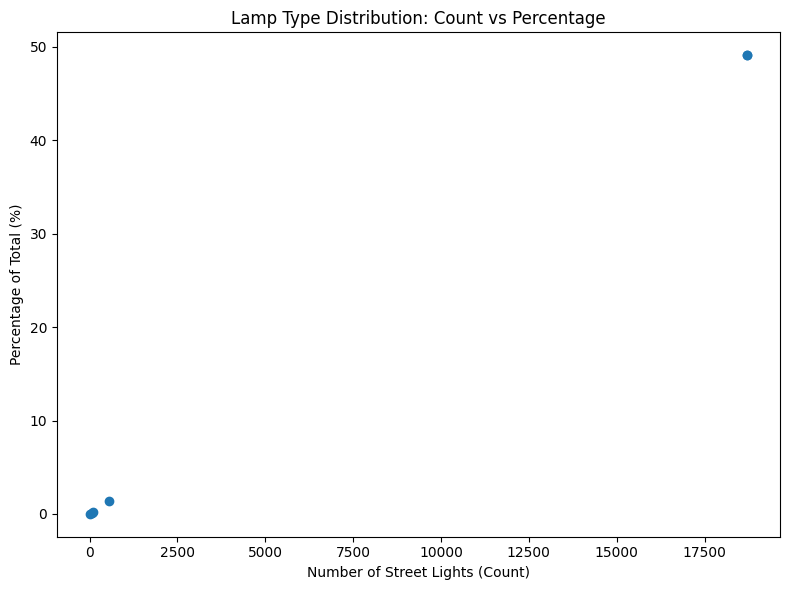

In [34]:


plt.figure(figsize=(8, 6))

plt.scatter(
    lamp_figure_df['Count'],
    lamp_figure_df['Percentage']
)

plt.xlabel("Number of Street Lights (Count)")
plt.ylabel("Percentage of Total (%)")
plt.title("Lamp Type Distribution: Count vs Percentage")

plt.tight_layout()
plt.show()


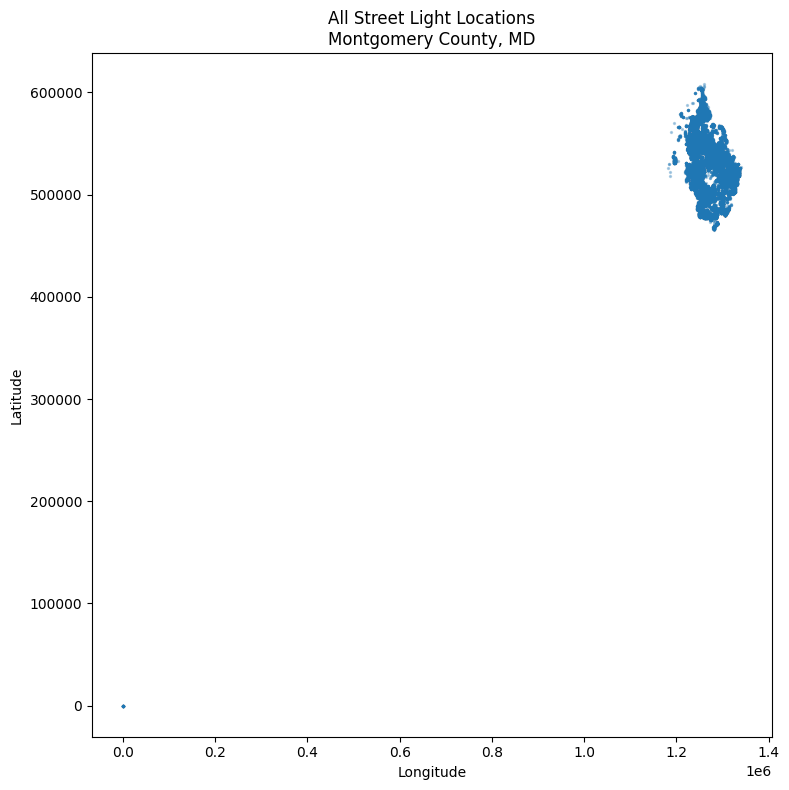

In [39]:
lat_col = 'Y'
lon_col = 'X'

scatter_df = df[[lat_col, lon_col]].apply(pd.to_numeric, errors='coerce')
scatter_df = scatter_df.dropna()

plt.figure(figsize=(8, 8))
plt.scatter(
    scatter_df[lon_col],
    scatter_df[lat_col],
    s=2,
    alpha=0.3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("All Street Light Locations\nMontgomery County, MD")

plt.tight_layout()
plt.show()

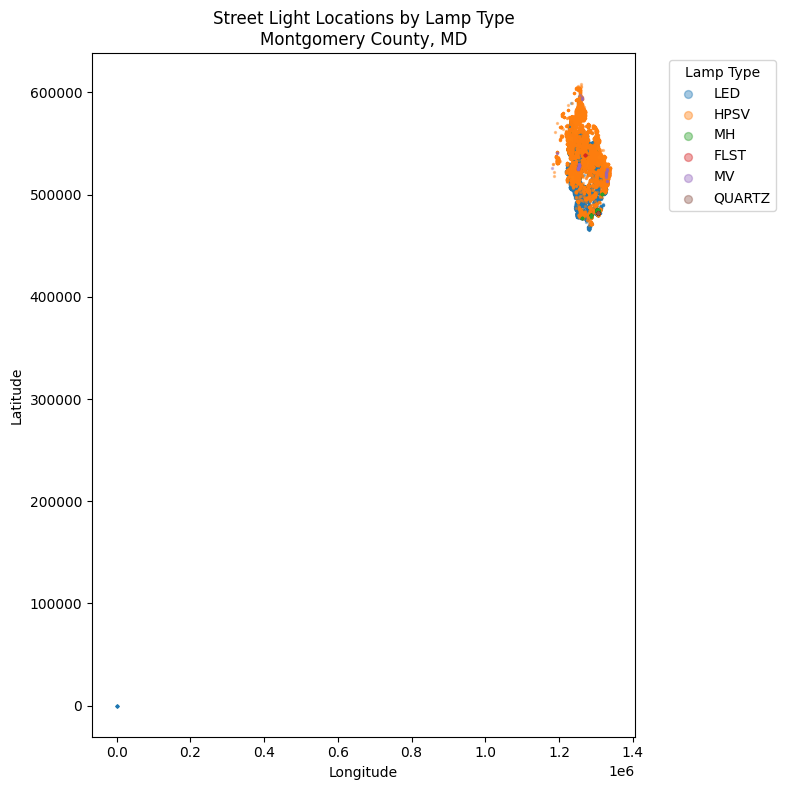

In [40]:
lat_col = 'Y'
lon_col = 'X'
color_col = 'LAMP_TYPE'

# Keep only needed columns & clean
scatter_df = df[[lat_col, lon_col, color_col]].copy()
scatter_df[[lat_col, lon_col]] = scatter_df[[lat_col, lon_col]].apply(
    pd.to_numeric, errors='coerce'
)
scatter_df = scatter_df.dropna()

plt.figure(figsize=(8, 8))

# Plot each lamp type as a different color
for lamp_type in scatter_df[color_col].unique():
    subset = scatter_df[scatter_df[color_col] == lamp_type]
    plt.scatter(
        subset[lon_col],
        subset[lat_col],
        s=2,
        alpha=0.4,
        label=lamp_type
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Street Light Locations by Lamp Type\nMontgomery County, MD")

plt.legend(
    title="Lamp Type",
    markerscale=4,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

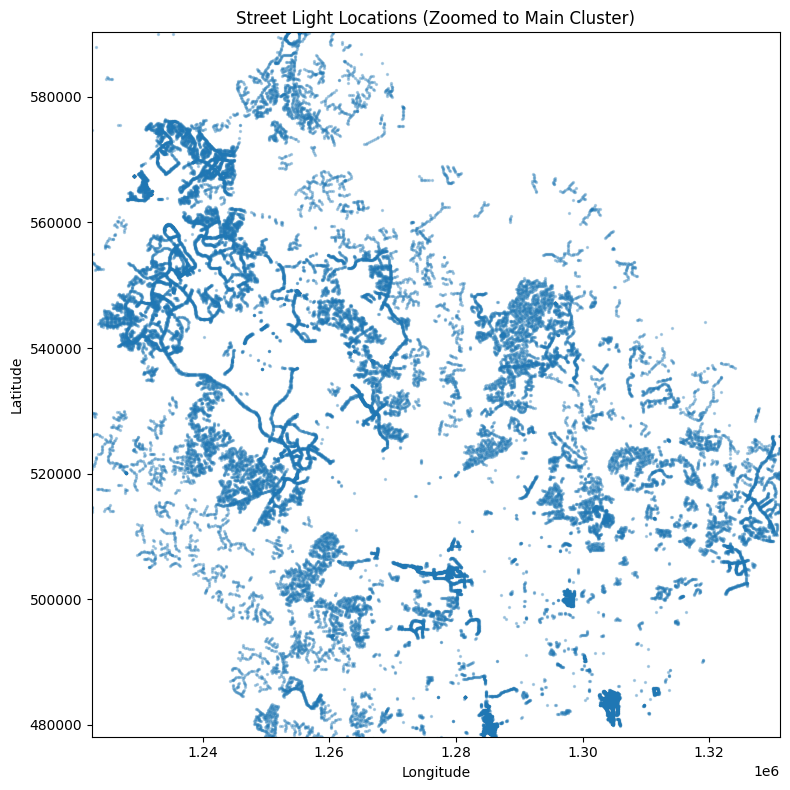

In [41]:
x_min, x_max = scatter_df[lon_col].quantile([0.01, 0.99])
y_min, y_max = scatter_df[lat_col].quantile([0.01, 0.99])

plt.figure(figsize=(8, 8))

plt.scatter(
    scatter_df[lon_col],
    scatter_df[lat_col],
    s=2,
    alpha=0.3
)

# Zoom to main data region
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Street Light Locations (Zoomed to Main Cluster)")

plt.tight_layout()
plt.show()

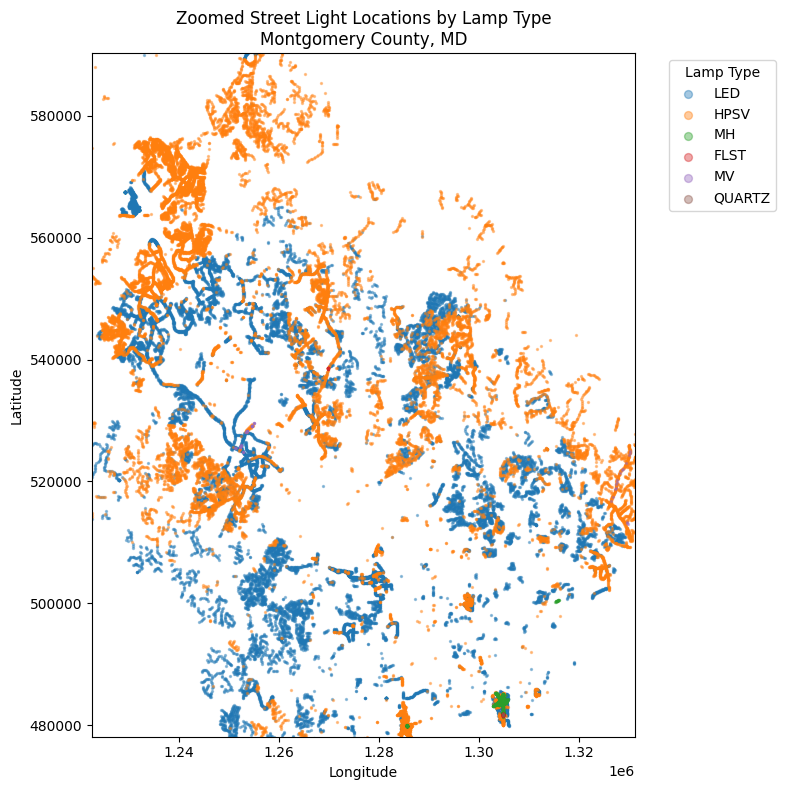

In [42]:
lat_col = 'Y'
lon_col = 'X'
color_col = 'LAMP_TYPE'

# Prepare data
scatter_df = df[[lat_col, lon_col, color_col]].copy()
scatter_df[[lat_col, lon_col]] = scatter_df[[lat_col, lon_col]].apply(
    pd.to_numeric, errors='coerce'
)
scatter_df = scatter_df.dropna()

# 🔍 Zoom bounds using percentiles (main data cluster)
x_min, x_max = scatter_df[lon_col].quantile([0.01, 0.99])
y_min, y_max = scatter_df[lat_col].quantile([0.01, 0.99])

plt.figure(figsize=(8, 8))

# Plot each lamp type in a different color
for lamp_type in scatter_df[color_col].unique():
    subset = scatter_df[scatter_df[color_col] == lamp_type]
    plt.scatter(
        subset[lon_col],
        subset[lat_col],
        s=2,
        alpha=0.4,
        label=lamp_type
    )

# Apply zoom
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Zoomed Street Light Locations by Lamp Type\nMontgomery County, MD")

plt.legend(
    title="Lamp Type",
    markerscale=4,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

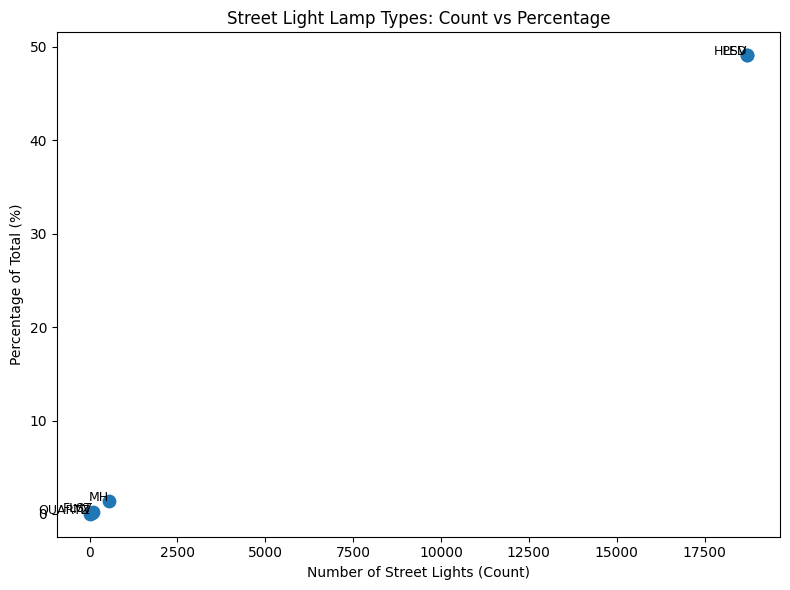

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(
    lamp_figure_df['Count'],
    lamp_figure_df['Percentage'],
    s=80
)

plt.xlabel("Number of Street Lights (Count)")
plt.ylabel("Percentage of Total (%)")
plt.title("Street Light Lamp Types: Count vs Percentage")

# Label each point with lamp type
for _, row in lamp_figure_df.iterrows():
    plt.text(
        row['Count'],
        row['Percentage'],
        row['Lamp_Type'],
        fontsize=9,
        ha='right'
    )

plt.tight_layout()
plt.show()

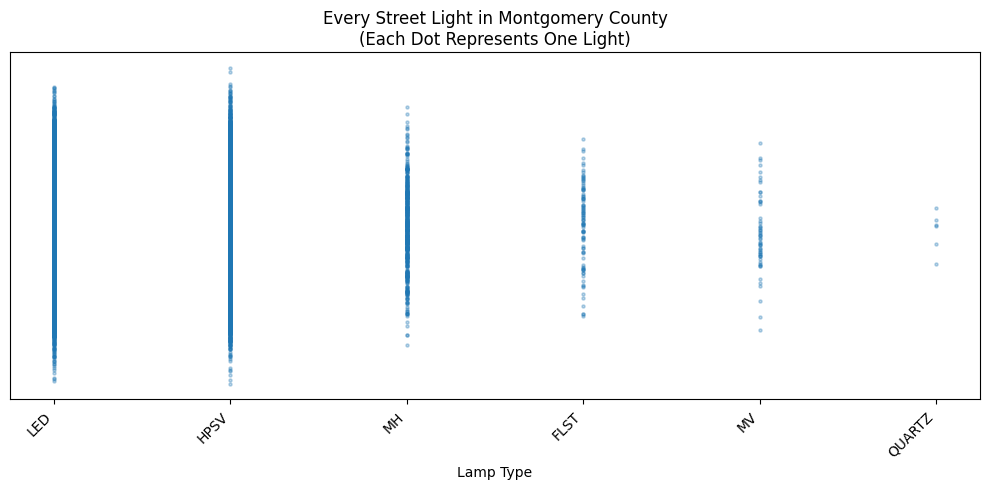

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Use only lamp type
plot_df = df[['LAMP_TYPE']].dropna()

# Create numeric positions for lamp types
types = plot_df['LAMP_TYPE'].unique()
x = plot_df['LAMP_TYPE'].map({t: i for i, t in enumerate(types)})

# Small random vertical jitter (just to separate points)
y = np.random.normal(0, 0.05, size=len(x))

plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=5, alpha=0.3)

plt.xticks(range(len(types)), types, rotation=45, ha='right')
plt.yticks([])

plt.xlabel("Lamp Type")
plt.title("Every Street Light in Montgomery County\n(Each Dot Represents One Light)")

plt.tight_layout()
plt.show()